# Beautified cumulative map figure (CONUS) — standardized to the Baltic style

This notebook is the CONUS counterpart to your Baltic "beautified" workflow.

It:
- reads an iNaturalist observations export CSV,
- filters to **CONUS** via a bounding box,
- renders a high-DPI, publication-style cumulative map (one PNG per year),
- writes a **final-year still** figure,
- optionally builds a **GIF** from the yearly frames.

Aesthetic choices (colors, legend style, caption layout, DPI) are matched to the Baltic notebook so the two figures look like a set.


In [ ]:
# Install dependencies (run once)
%pip install -q pandas geopandas matplotlib shapely pyproj imageio


In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# --------------------
# INPUTS
# --------------------
# Point this at your iNaturalist export CSV.
# If you keep the file next to this notebook, just put its filename here.
CSV_PATH = Path('data/amanita_phalloides/observations-663867.csv')  # <-- CHANGE THIS

# --------------------
# OUTPUTS
# --------------------
OUTDIR = Path('outputs/conus_beautified')
FRAMES_DIR = OUTDIR / 'frames'
FRAMES_DIR.mkdir(parents=True, exist_ok=True)
FINAL_FIG_PATH = OUTDIR / 'final_year.png'
GIF_PATH = OUTDIR / 'cumulative.gif'

# --------------------
# CONUS FILTER (approximate bounding box)
# --------------------
# Excludes AK/HI and most territories. Adjust if you want Mexico/Canada edges tighter.
LAT_MIN, LAT_MAX = 24.0, 50.0
LON_MIN, LON_MAX = -125.0, -66.0

# --------------------
# STYLE — matched to Baltic notebook
# --------------------
DPI = 240
FIGSIZE = (10.0, 8.0)

HIGHLIGHT_NEW = True
S_OLD = 25         # marker size for older cumulative points
S_NEW = 35         # marker size for points first appearing in a year
ALPHA_OLD = 0.70
ALPHA_NEW = 0.90

# Colors (explicit because you asked to beautify)
LAND_COLOR = '#f3efe3'
WATER_COLOR = '#eaf2f8'
BORDER_COLOR = '#6c7a89'
POINT_OLD_COLOR = "#0080ffff"
POINT_NEW_COLOR = '#c0392b'

FPS = 3
HOLD_LAST_N_FRAMES = 5

# Projection: NAD83 / Conus Albers (good for contiguous US)
TARGET_CRS = 'EPSG:5070'

# Performance knob: subsample cumulative points if extremely dense
MAX_POINTS_PER_FRAME = None  # e.g., 150_000 or None

# Matplotlib typography defaults
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 15,
    'axes.titlepad': 14,
    'figure.facecolor': 'white'
})


In [2]:
# Load CSV
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"CSV not found at {CSV_PATH}. Put your export CSV next to the notebook or set CSV_PATH."
    )

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print('Loaded:', CSV_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head())

if len(df_raw) == 0:
    raise ValueError('CSV has 0 rows (headers-only). Re-export from iNaturalist and try again.')


Loaded: data/amanita_phalloides/observations-663867.csv
Shape: (5651, 9)


,id,observed_on,user_id,user_name,quality_grade,latitude,longitude,scientific_name,common_name
0,3687,2009-11-22,308,NaN,research,37.397453,-122.316422,Amanita phalloides,Deathcap
1,3757,2009-11-28,1,Ken-ichi Ueda,research,37.770615,-122.123238,Amanita phalloides,Deathcap
2,6163,2010-03-20,382,NaN,research,34.377331,-118.441803,Amanita phalloides,Deathcap
3,37526,2011-10-28,1,Ken-ichi Ueda,research,37.195912,-122.294827,Amanita phalloides,Deathcap
4,38441,2011-11-04,2873,James Maughn,research,37.027718,-122.156296,Amanita phalloides,Deathcap


In [12]:
# Standardize coordinates + date
df = df_raw.copy()

# Coordinates
if {'latitude', 'longitude'}.issubset(df.columns):
    df['lat'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')
elif 'location' in df.columns:
    parts = df['location'].astype(str).str.split(',', n=1, expand=True)
    df['lat'] = pd.to_numeric(parts[0], errors='coerce')
    df['lon'] = pd.to_numeric(parts[1], errors='coerce')
else:
    raise KeyError('Need latitude/longitude columns or a location column ("lat,lon").')

# Date
date_col = None
for c in ['time_observed_at', 'observed_on', 'observed_on_string', 'created_at', 'time_created_at']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('Could not find a usable date column (e.g., time_observed_at / observed_on).')

df['date'] = pd.to_datetime(df[date_col], errors='coerce', utc=True)
df = df.dropna(subset=['lat', 'lon', 'date']).copy()
df['year'] = df['date'].dt.year.astype(int)

# Filter to CONUS bbox
df = df[df['lat'].between(LAT_MIN, LAT_MAX) & df['lon'].between(LON_MIN, LON_MAX)].copy()

if len(df) == 0:
    raise ValueError('No rows remain after CONUS bbox filter. Adjust bounds or verify your export region.')

print('After cleaning + CONUS filter:', df.shape)
print('Year range:', int(df['year'].min()), '→', int(df['year'].max()))

taxa = sorted(df['scientific_name'].dropna().unique().tolist()) if 'scientific_name' in df.columns else []
taxon_label = taxa[0] 
print('Taxon label:', taxon_label)

display(df[['date','year','lat','lon']].head())


After cleaning + CONUS filter: (5651, 13)
Year range: 2000 → 2026
Taxon label: Amanita phalloides


,date,year,lat,lon
0,2009-11-22 00:00:00+00:00,2009,37.397453,-122.316422
1,2009-11-28 00:00:00+00:00,2009,37.770615,-122.123238
2,2010-03-20 00:00:00+00:00,2010,34.377331,-118.441803
3,2011-10-28 00:00:00+00:00,2011,37.195912,-122.294827
4,2011-11-04 00:00:00+00:00,2011,37.027718,-122.156296


year
2000       1
2004       1
2006       2
2007       9
2008       5
2009       7
2010      13
2011      13
2012      12
2013       5
2014      57
2015      14
2016     263
2017      56
2018     142
2019     315
2020     216
2021     852
2022     547
2023     589
2024     499
2025    2012
2026      21
dtype: int64

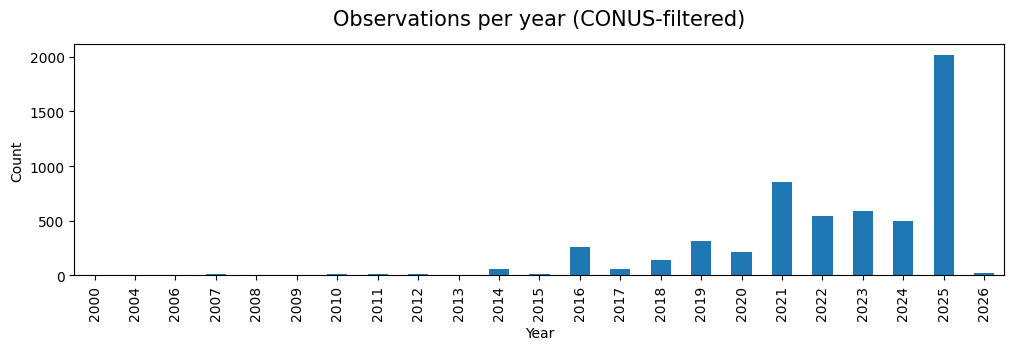

In [13]:
# Quick per-year counts
year_counts = df.groupby('year').size().sort_index()
display(year_counts)
ax = year_counts.plot(kind='bar', figsize=(12,3), title='Observations per year (CONUS-filtered)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.show()


In [14]:
# Build GeoDataFrames + basemap
gdf_obs = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['lon'], df['lat'])],
    crs='EPSG:4326'
)

world = gpd.read_file("https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson")
bbox_geom = box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)

# Clip countries to bbox (WGS84), then project
world_clip = world[world.intersects(bbox_geom)].copy()
world_clip = world_clip.to_crs(TARGET_CRS)
gdf_obs_proj = gdf_obs.to_crs(TARGET_CRS)

# Compute plot extent from projected bbox
bbox_proj = gpd.GeoSeries([bbox_geom], crs='EPSG:4326').to_crs(TARGET_CRS).iloc[0]
XMIN, YMIN, XMAX, YMAX = bbox_proj.bounds

years = list(range(int(df['year'].min()), int(df['year'].max()) + 1))
print('Frames for years:', years[0], '→', years[-1], f"({len(years)} frames)")


URLError: <urlopen error [Errno 8] nodename nor servname provided, or not known>

In [ ]:
def plot_frame(year: int, save_path: Path | None = None):
    d_cum = gdf_obs_proj[gdf_obs_proj['year'] <= year]
    d_new = gdf_obs_proj[gdf_obs_proj['year'] == year]

    if MAX_POINTS_PER_FRAME is not None and len(d_cum) > MAX_POINTS_PER_FRAME:
        d_cum = d_cum.sample(MAX_POINTS_PER_FRAME, random_state=0)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    ax.set_facecolor(WATER_COLOR)
    fig.patch.set_facecolor('white')

    # Basemap
    world_clip.plot(ax=ax, color=LAND_COLOR, edgecolor=BORDER_COLOR, linewidth=0.7, zorder=1)

    # Cumulative points (old)
    ax.scatter(
        d_cum.geometry.x,
        d_cum.geometry.y,
        s=S_OLD,
        alpha=ALPHA_OLD,
        c=POINT_OLD_COLOR,
        linewidths=0,
        zorder=2,
        label='Cumulative observations'
    )

    # New points for the year
    if HIGHLIGHT_NEW:
        ax.scatter(
            d_new.geometry.x,
            d_new.geometry.y,
            s=S_NEW,
            alpha=ALPHA_NEW,
            c=POINT_NEW_COLOR,
            linewidths=0.25,
            edgecolors='white',
            zorder=3,
            label=f'New in {year}'
        )

    # Extent + clean axes
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    n_cum = int((df['year'] <= year).sum())
    n_new = int((df['year'] == year).sum())

    # Title block
    ax.set_title(
        f"{taxon_label} — cumulative iNaturalist observations through {year}",
        fontsize=15,
        pad=14,
    )
    ax.text(
        0.5, 1.01,
        f"Cumulative n={n_cum:,} (new in {year}: {n_new:,})",
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=10,
        color='#2c3e50',
        alpha=0.9,
    )

    # Caption / provenance
    caption = (
        "Data: iNaturalist export (verifiable). "
        f"CONUS bbox: lat {LAT_MIN:.2f}–{LAT_MAX:.2f}, lon {LON_MIN:.2f}–{LON_MAX:.2f}. "
        f"Projection: {TARGET_CRS}."
    )
    ax.text(
        0.01, 0.01, caption,
        transform=ax.transAxes,
        fontsize=8.5,
        va='bottom', ha='left',
        color='#2c3e50',
        alpha=0.85,
    )

    # Legend
    leg = ax.legend(
        loc='upper left',
        frameon=True,
        framealpha=0.85,
        fontsize=9,
        borderpad=0.6,
    )
    leg.get_frame().set_linewidth(0.0)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
    return fig


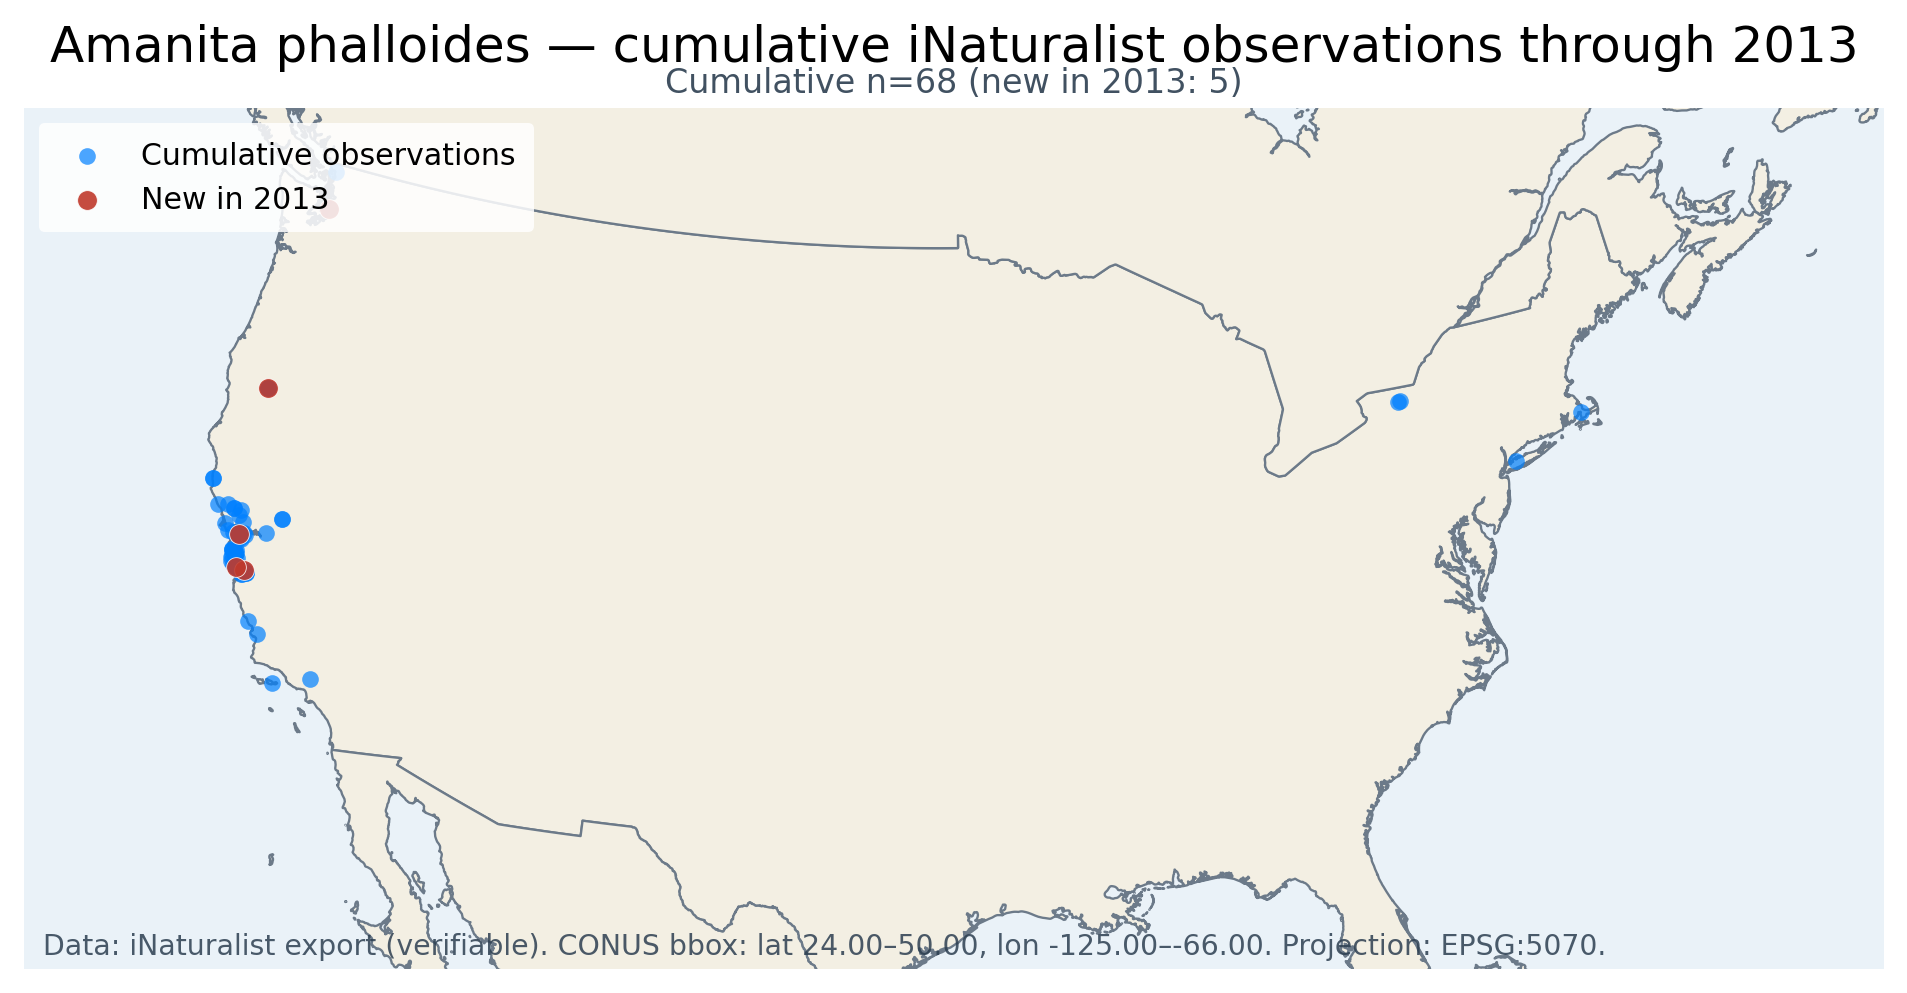

In [15]:
# Preview a mid-series frame
mid_year = years[len(years)//2]
fig = plot_frame(mid_year)
plt.show()


In [16]:
# Render PNG frames
frame_paths = []
for y in years:
    p = FRAMES_DIR / f"frame_{y}.png"
    plot_frame(y, save_path=p)
    frame_paths.append(p)

print('Wrote', len(frame_paths), 'frames to', FRAMES_DIR.resolve())


Wrote 27 frames to /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/conus_beautified/frames


In [17]:
# Write a final-year still (high resolution)
plot_frame(years[-1], save_path=FINAL_FIG_PATH)
print('Wrote final figure:', FINAL_FIG_PATH.resolve())


Wrote final figure: /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/conus_beautified/final_year.png


In [18]:
# Build GIF (optional; keeps aesthetic consistent with Baltic)
frames = [imageio.imread(p) for p in frame_paths]
if HOLD_LAST_N_FRAMES and HOLD_LAST_N_FRAMES > 0:
    frames.extend([frames[-1]] * HOLD_LAST_N_FRAMES)

imageio.mimsave(GIF_PATH, frames, fps=FPS, loop=0)
print('Wrote GIF:', GIF_PATH.resolve())


Wrote GIF: /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/conus_beautified/cumulative.gif


## Notes

- This uses Natural Earth *countries* as the basemap (quick + dependency-light). If you want **state boundaries**, we can add them, but it typically requires a US admin-1 shapefile (Census TIGER/Cartopy/Natural Earth admin-1) and one extra install/download.
- To make this match the Baltic look even more closely, keep the same `DPI`, `FIGSIZE`, and color hex codes between the two notebooks.
